# Buffett's Alpha — the quant teardown 🎩

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Any_alpha_left%3F: Busted](https://img.shields.io/badge/Any_alpha_left%3F-Busted-8b949e?style=flat-square)

**Claim under test** (Frazzini, Kabiller & Pedersen, *Buffett's Alpha*, FAJ 2018): Berkshire's four-decade CAPM alpha is real (*t* > 3), is explained by quality + low-beta exposure financed with cheap insurance-float leverage, and has been fading.

**Design.** BRK-A monthly total return (no dividend since 1967 ⇒ adjusted price = total return) vs a spliced US-market total return (^GSPC + Shiller dividend yield → 1993-01, SPY thereafter; labeled per row), both in excess of the previous month-end ^IRX/12. Newey-West HAC everywhere; sub-period contrasts get a HAC *t* on the *difference*; the factor attribution uses investable ETF proxies (QUAL, USMV) and is labeled **factor-lite**. As-of **2026-06-30**, fingerprint `96d18b13a5da`.

**Named biases:** selection-on-success (the fund is studied because it won); our tape misses 1976-80 (biases the full-sample alpha *down* vs FKP); QUAL/USMV exist only from 2011-13 (the attribution cannot reach the high-alpha era).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from buffetts_alpha import data, strategy as st

HAVE_REAL = data.have_real()
DF = data.load_real() if HAVE_REAL else None
print("real tape cached:", HAVE_REAL,
      "| months:", (0 if DF is None else len(DF)),
      "| span:", ("-" if DF is None else f"{DF.index.min().date()} -> {DF.index.max().date()}"))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1980-04-30', 'end': '2026-06-30', 'n': 555, 'years': 46.2, 'splice_pre': 154, 'splice_spy': 401, 'wealth_brk': 2880, 'wealth_mkt': 220, 'brk_ann': 18.8, 'mkt_ann': 12.37, 'alpha_ann': 9.46, 't_alpha': 3.47, 'beta': 0.7, 'r2': 0.24, 'ir': 0.5, 'nw_lags': 5, 'brk_exc': 15.64, 'mkt_exc': 8.88, 'brk_sharpe': 0.72, 'mkt_sharpe': 0.59, 'brk_vol': 21.6, 'fkp': {'alpha': 12.36, 't': 3.4, 'beta': 0.68, 'n': 381, 'brk_sharpe': 0.72, 'mkt_sharpe': 0.44}, 'decades': [('1980s', 23.39, 3.55, 0.82, 31.25, 9.58, 117), ('1990s', 5.07, 0.76, 0.92, 16.7, 12.68, 120), ('2000s', 6.01, 1.28, 0.47, 4.88, -2.41, 120), ('2010s', 5.15, 1.28, 0.6, 12.89, 12.9, 120), ('2020s*', 2.06, 0.34, 0.71, 11.4, 13.13, 78)], 'roll': {'n_windows': 436, 'first': '1990-03-31', 'peak': 20.34, 'peak_at': '1990-03-31', 'latest': 1.83, 'latest_t': 0.46, 'latest_beta': 0.75, 'last_sig': '2002-12-31', 'share_sig': 25.0}, 'fade': {'early_alpha': 12.97, 'early_t': 3.48, 'd_alpha': -10.98, 'd_t': -2.38, 'd_beta': 0.08, 'd_beta_t': 0.65, 'split': '2010-12-31'}, 'last15': {'alpha': 2.66, 't': 0.89, 'beta': 0.75, 'n': 180, 'brk_sharpe': 0.74, 'mkt_sharpe': 0.9, 'wealth_brk': 6.45, 'wealth_mkt': 7.37, 'start': '2011-07-31'}, 'flite': {'start': '2013-08-31', 'n': 155, 'capm_alpha': 1.54, 'capm_t': 0.46, 'capm_beta': 0.75, 'r2_capm': 0.41, 'full_alpha': 1.43, 'full_t': 0.44, 'r2_full': 0.51, 'b_mkt': -0.17, 't_mkt': -0.37, 'b_qual': 0.3, 't_qual': 0.68, 'b_usmv': 0.89, 't_usmv': 3.77}, 'syn': [(0.0, 0.27, 0.11, 10), (6.0, 6.27, 2.56, 70)], 'fingerprint': '96d18b13a5da'}


real tape cached: True | months: 555 | span: 1980-04-30 -> 2026-06-30


## 1 · Data stamp

> 💡 **In plain words.** One monthly table: Berkshire's return, the market's return (with dividends), and the T-bill rate you could have locked at the start of each month. Everything below is regressions on these three columns.

In [2]:
if HAVE_REAL:
    from quantlab import repro
    print(repro.data_stamp('ba_monthly', DF, cols=['brk','mkt','rf'], asof=data.AS_OF))
    print(DF['mkt_src'].value_counts().to_string())
    print(f"expected fingerprint: {R['fingerprint']}")
else:
    print('cache missing — quoting frozen numbers from R throughout')

[data] ba_monthly: 555 rows  1980-04-30 -> 2026-06-30  as-of 2026-06-30  fingerprint=96d18b13a5da
mkt_src
spy_tr             401
gspc+shiller_dy    154
expected fingerprint: 96d18b13a5da


## 2 · Full-sample CAPM — the headline

Excess-vs-excess OLS with Newey-West (Bartlett) HAC standard errors, rule-of-thumb lags. The desk bar is **HAC *t* ≥ 2 on the real tape**.

In [3]:
if HAVE_REAL:
    c = st.capm(DF)
    cf = st.capm(DF, end='2011-12-31')
    print(f"FULL 1980-04 -> 2026-06 (n={c['n']}, NW lags={c['lags']}):")
    print(f"  alpha {c['alpha_ann_pct']:+.2f}%/yr  HAC t = {c['t_alpha']:+.2f}   "
          f"beta {c['beta']:.2f} (t={c['t_beta']:.1f})   R2={c['r2']:.2f}   IR={c['ir']:.2f}")
    print(f"  excess: BRK {c['brk_exc_ann_pct']:+.2f}%/yr vs mkt {c['mkt_exc_ann_pct']:+.2f}%/yr | "
          f"Sharpe {c['brk_sharpe']:.2f} vs {c['mkt_sharpe']:.2f} (excess-vs-excess)")
    print(f"FKP-era -> 2011-12 (n={cf['n']}):")
    print(f"  alpha {cf['alpha_ann_pct']:+.2f}%/yr  HAC t = {cf['t_alpha']:+.2f}   beta {cf['beta']:.2f}  "
          f"Sharpe {cf['brk_sharpe']:.2f} vs {cf['mkt_sharpe']:.2f}")
else:
    print(f"frozen: alpha +{R['alpha_ann']}%/yr t={R['t_alpha']} beta {R['beta']} | "
          f"FKP-era +{R['fkp']['alpha']}%/yr t={R['fkp']['t']}")

FULL 1980-04 -> 2026-06 (n=555, NW lags=5):
  alpha +9.46%/yr  HAC t = +3.47   beta 0.70 (t=10.8)   R2=0.24   IR=0.50
  excess: BRK +15.64%/yr vs mkt +8.88%/yr | Sharpe 0.72 vs 0.59 (excess-vs-excess)
FKP-era -> 2011-12 (n=381):
  alpha +12.36%/yr  HAC t = +3.40   beta 0.68  Sharpe 0.72 vs 0.44


> 💡 **In plain words.** Over 46 years Buffett beat the T-bill by ~15.6%/yr while the market managed ~8.9%/yr — and he did it with *less* market risk (beta 0.70). The +9.5%/yr left over is 3.5 standard errors from zero: not luck. FKP's *t* > 3 replicates on free data (*t* = 3.40 on their era).

**Scatter + fit:** the intercept IS the claim.

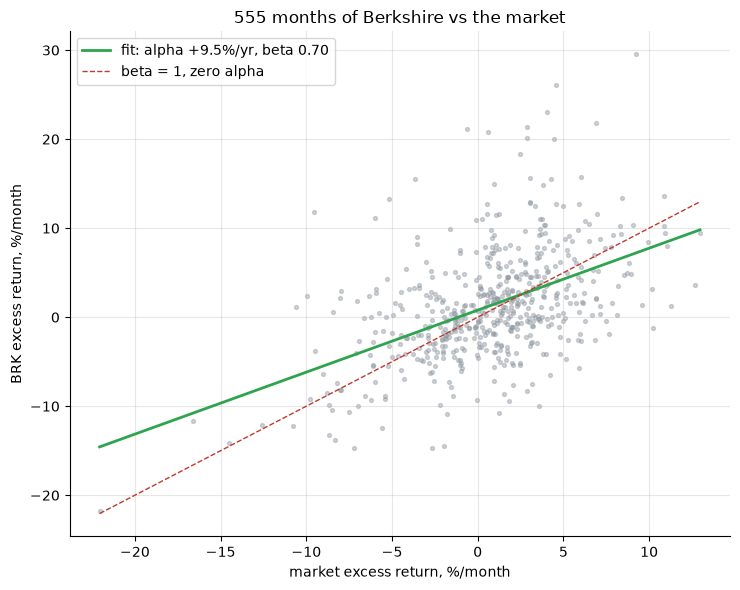

In [4]:
if HAVE_REAL:
    yb = (DF['brk'] - DF['rf']) * 100; xm = (DF['mkt'] - DF['rf']) * 100
    c = st.capm(DF)
    fig, ax = plt.subplots(figsize=(7.5, 6))
    ax.scatter(xm, yb, s=8, alpha=.4, color=GREY)
    xs = np.linspace(xm.min(), xm.max(), 50)
    ax.plot(xs, c['alpha_m']*100 + c['beta']*xs, color=GREEN, lw=2,
            label=f"fit: alpha {c['alpha_ann_pct']:+.1f}%/yr, beta {c['beta']:.2f}")
    ax.plot(xs, xs, color=RED, lw=1, ls='--', label='beta = 1, zero alpha')
    ax.set_xlabel('market excess return, %/month'); ax.set_ylabel('BRK excess return, %/month')
    ax.set_title('555 months of Berkshire vs the market'); ax.legend()
    plt.tight_layout(); plt.show()

## 3 · The decay — decades, rolling windows, and a t-test on the fade itself

In [5]:
if HAVE_REAL:
    dt = st.decade_table(DF)
    print(dt.round(2).to_string())
else:
    for d in R['decades']: print(d)

        months  alpha_ann_pct  t_alpha  beta  brk_exc_ann_pct  mkt_exc_ann_pct
decade                                                                        
1980s      117          23.39     3.55  0.82            31.25             9.58
1990s      120           5.07     0.76  0.92            16.70            12.68
2000s      120           6.01     1.28  0.47             4.88            -2.41
2010s      120           5.15     1.28  0.60            12.89            12.90
2020s       78           2.06     0.34  0.71            11.40            13.13


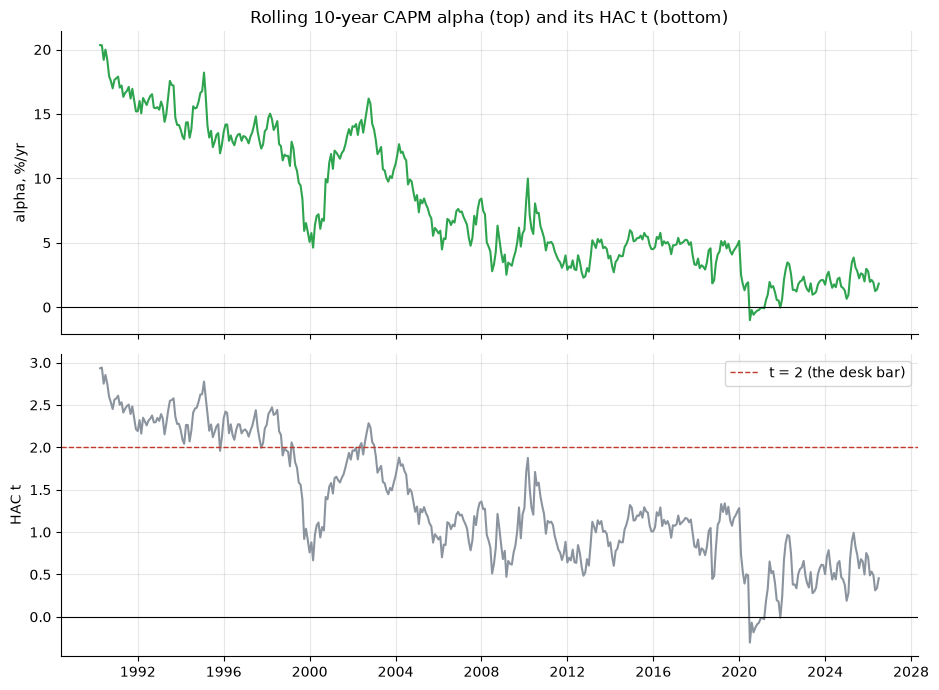

peak +20.34%/yr at 1990-03-31 | latest +1.83%/yr (t=+0.46) | last t>=2 window ends 2002-12-31 | share t>=2: 25.0%


In [6]:
if HAVE_REAL:
    ra = st.rolling_alpha(DF, window=120)
    fig, axes = plt.subplots(2, 1, figsize=(9.5, 7), sharex=True)
    axes[0].plot(ra.index, ra['alpha_ann_pct'], color=GREEN, lw=1.5)
    axes[0].axhline(0, color='k', lw=.8)
    axes[0].set_ylabel('alpha, %/yr'); axes[0].set_title('Rolling 10-year CAPM alpha (top) and its HAC t (bottom)')
    axes[1].plot(ra.index, ra['t_alpha'], color=GREY, lw=1.5)
    axes[1].axhline(2, color=RED, lw=1, ls='--', label='t = 2 (the desk bar)')
    axes[1].axhline(0, color='k', lw=.8)
    axes[1].set_ylabel('HAC t'); axes[1].legend()
    plt.tight_layout(); plt.show()
    print(f"peak {ra['alpha_ann_pct'].max():+.2f}%/yr at {ra['alpha_ann_pct'].idxmax().date()} | "
          f"latest {ra['alpha_ann_pct'].iloc[-1]:+.2f}%/yr (t={ra['t_alpha'].iloc[-1]:+.2f}) | "
          f"last t>=2 window ends {ra[ra['t_alpha'] >= 2].index.max().date()} | "
          f"share t>=2: {(ra['t_alpha'] >= 2).mean()*100:.1f}%")

> 💡 **In plain words.** No ten-year stretch ending after 2002 can certify alpha on its own. And the *change* is not noise — putting a post-2010 dummy in one regression gives the fade its own *t*-stat:

In [7]:
if HAVE_REAL:
    fd = st.subperiod_fade(DF, split='2010-12-31')
    print(f"early alpha (-> 2010-12): {fd['alpha_early_ann_pct']:+.2f}%/yr (t={fd['t_alpha_early']:+.2f})")
    print(f"alpha change after 2010 : {fd['d_alpha_ann_pct']:+.2f} pp/yr  HAC t = {fd['t_d_alpha']:+.2f}")
    print(f"beta  change after 2010 : {fd['d_beta']:+.2f} (t={fd['t_d_beta']:+.2f}) — the fade is alpha, not risk")
else:
    print(f"frozen: d_alpha {R['fade']['d_alpha']} pp/yr, t {R['fade']['d_t']}")

early alpha (-> 2010-12): +12.97%/yr (t=+3.48)
alpha change after 2010 : -10.98 pp/yr  HAC t = -2.38
beta  change after 2010 : +0.08 (t=+0.65) — the fade is alpha, not risk


## 4 · Third axis — any alpha left in the last 15 years?

The out-of-sample continuation of FKP (their tape ends 2011).

In [8]:
if HAVE_REAL:
    c15 = st.capm(DF, start='2011-07-01')
    d15 = DF[DF.index >= '2011-07-01']
    print(f"2011-07 -> 2026-06 (n={c15['n']}):")
    print(f"  alpha {c15['alpha_ann_pct']:+.2f}%/yr  HAC t = {c15['t_alpha']:+.2f}   beta {c15['beta']:.2f}")
    print(f"  Sharpe: BRK {c15['brk_sharpe']:.2f} vs mkt {c15['mkt_sharpe']:.2f} (excess-vs-excess)")
    print(f"  $1 -> BRK ${float((1+d15['brk']).prod()):.2f} vs market ${float((1+d15['mkt']).prod()):.2f}")
else:
    print(f"frozen: alpha +{R['last15']['alpha']}%/yr t={R['last15']['t']}, "
          f"$ {R['last15']['wealth_brk']} vs {R['last15']['wealth_mkt']}")

2011-07 -> 2026-06 (n=180):
  alpha +2.66%/yr  HAC t = +0.89   beta 0.75
  Sharpe: BRK 0.74 vs mkt 0.90 (excess-vs-excess)
  $1 -> BRK $6.45 vs market $7.37


> 💡 **In plain words.** Zero alpha, a worse Sharpe than the index, and a lagging dollar. **BUSTED** — nothing is left for today's buyer. That is *also* a confirmation of FKP: they called the fade in 2013.

## 5 · Factor-lite attribution — the FKP mechanism, ETF-proxy edition

FKP explain Buffett with BAB (low-beta) + QMJ (quality). Those academic long-short factors aren't freely available here, so we use the **investable proxies** USMV (min-vol) and QUAL (quality), excess of T-bills, on their common window (2013-08 →). Honest limitation: this window post-dates the alpha, so the test is of the *style signature*, not a re-run of FKP's full attribution.

In [9]:
if HAVE_REAL:
    fl = st.factor_lite(DF)
    print(f"window {fl['start']} -> {fl['end']} (n={fl['n']})")
    print(f"CAPM alone   : alpha {fl['capm_alpha_ann_pct']:+.2f}%/yr (t={fl['capm_t_alpha']:+.2f})  "
          f"beta {fl['capm_beta']:.2f}  R2={fl['r2_capm']:.2f}")
    print(f"+ QUAL + USMV: alpha {fl['full_alpha_ann_pct']:+.2f}%/yr (t={fl['full_t_alpha']:+.2f})  R2={fl['r2_full']:.2f}")
    print(f"loadings: mkt {fl['b_mkt']:+.2f} (t={fl['t_mkt']:+.2f}) | QUAL {fl['b_qual']:+.2f} "
          f"(t={fl['t_qual']:+.2f}) | USMV {fl['b_usmv']:+.2f} (t={fl['t_usmv']:+.2f})")
else:
    print(f"frozen: USMV loading {R['flite']['b_usmv']} (t={R['flite']['t_usmv']})")

window 2013-08-31 -> 2026-06-30 (n=155)
CAPM alone   : alpha +1.54%/yr (t=+0.46)  beta 0.75  R2=0.41
+ QUAL + USMV: alpha +1.43%/yr (t=+0.44)  R2=0.51
loadings: mkt -0.17 (t=-0.37) | QUAL +0.30 (t=+0.68) | USMV +0.89 (t=+3.77)


> 💡 **In plain words.** Modern Berkshire prices like a **min-vol index fund**: the USMV loading (+0.89, *t* = 3.77) soaks up the market beta and lifts R² from 0.41 to 0.51. The style FKP identified is now literally purchasable for 15 bps — which is precisely why the alpha is gone.

## 6 · Synthetic control — the machinery is faithful

Seeded (market, manager) worlds with AR(1) idiosyncratic noise and a **planted** CAPM alpha, averaged over **20 seeds**. The null must stay quiet; the planted alpha must light up. *(Machinery proof only — never market evidence.)*

In [10]:
for a in (0.0, 0.005):
    ts, als = [], []
    for s in range(628, 648):
        c = st.capm(data.synthetic_world(alpha_m=a, seed=s))
        ts.append(c['t_alpha']); als.append(c['alpha_ann_pct'])
    ts, als = np.array(ts), np.array(als)
    print(f"planted {a*12*100:4.1f}%/yr: mean recovered {als.mean():+.2f}%/yr  "
          f"mean HAC t {ts.mean():+.2f}  share |t|>=2: {np.mean(np.abs(ts)>=2)*100:.0f}%")

planted  0.0%/yr: mean recovered +0.27%/yr  mean HAC t +0.11  share |t|>=2: 10%


planted  6.0%/yr: mean recovered +6.27%/yr  mean HAC t +2.56  share |t|>=2: 70%


## 7 · Verdict

| Axis | Stamp | The number that decides |
|---|---|---|
| Signal | **REAL** | full-sample HAC *t* = **3.47** (alpha +9.46%/yr, beta 0.70); FKP-era *t* = 3.40 — with the **selection-on-success** caveat named |
| Tradability | **FRAGILE** | fade = **−10.98 pp/yr** post-2010 (HAC *t* = −2.38); no 10-y window clears *t* ≥ 2 since 2002; buying BRK today buys beta 0.75, alpha ≈ 0 |
| Any alpha left? | **BUSTED** | last 15y: +2.66%/yr, *t* = 0.89; Sharpe 0.74 vs 0.90; $6.45 vs $7.37 per dollar |

---
*Reproduce: `python examples/verify.py`. Sources: [docs/references.md](../docs/references.md). As-of 2026-06-30, fingerprint `96d18b13a5da`. Not investment advice.*